In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
!pip install libsvm
!pip install tensorflow
!pip install cvxopt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.6/170.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for libsvm: filename=libsvm-3.23.0.4-cp310-cp310-linux_x86_64.whl size=251405 sha256=f676bb2ed67da95259af4762caf13f4b2fe738ab330a0beaf248945705c05bc0
  Stored in directory: /root/.cache/pip/wheels/79/c7/19/a8c85928f8e629654b8e1adb3c8091f0bb77344d0ee9954a85
Successfully built libsvm


In [2]:
from google.colab import files
uploaded = files.upload()


Saving Modified_CreditCardData.csv to Modified_CreditCardData.csv


In [3]:
df = pd.read_csv("Modified_CreditCardData.csv")

In [4]:
df.shape

(3000, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction ID          3000 non-null   object 
 1   Date                    3000 non-null   object 
 2   Day of Week             3000 non-null   object 
 3   Time                    3000 non-null   int64  
 4   Type of Card            3000 non-null   object 
 5   Entry Mode              3000 non-null   object 
 6   Amount                  3000 non-null   object 
 7   Type of Transaction     3000 non-null   object 
 8   Merchant Group          2997 non-null   object 
 9   Country of Transaction  3000 non-null   object 
 10  Shipping Address        3000 non-null   object 
 11  Country of Residence    3000 non-null   object 
 12  Gender                  2999 non-null   object 
 13  Age                     3000 non-null   float64
 14  Bank                    3000 non-null   

In [6]:
df.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [7]:
null_counts = df.isnull().sum()
print(null_counts)

Transaction ID            0
Date                      0
Day of Week               0
Time                      0
Type of Card              0
Entry Mode                0
Amount                    0
Type of Transaction       0
Merchant Group            3
Country of Transaction    0
Shipping Address          0
Country of Residence      0
Gender                    1
Age                       0
Bank                      0
Fraud                     0
dtype: int64


In [8]:
#Convert Gender from categorical to numerical values
dict_Type_of_Card = {'Visa': 1, 'MasterCard':0}
df.replace({'Type 0f Card': dict_Type_of_Card}, inplace = True)

# Replacing missing values
df['Merchant Group'] = df['Merchant Group'].fillna('personal')


In [9]:
#Convert Gender from categorical to numerical values
dict_Gender = {'M': 1, 'F':0}
df.replace({'Gender': dict_Gender}, inplace = True)

# Replace with -1 for missing gender
df['Gender'] = df['Gender'].fillna(-1)

<ipython-input-9-75b669f912b6>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Gender': dict_Gender}, inplace = True)


In [10]:
null_counts = df.isnull().sum()
print(null_counts)

Transaction ID            0
Date                      0
Day of Week               0
Time                      0
Type of Card              0
Entry Mode                0
Amount                    0
Type of Transaction       0
Merchant Group            0
Country of Transaction    0
Shipping Address          0
Country of Residence      0
Gender                    0
Age                       0
Bank                      0
Fraud                     0
dtype: int64


<Figure size 1000x600 with 0 Axes>

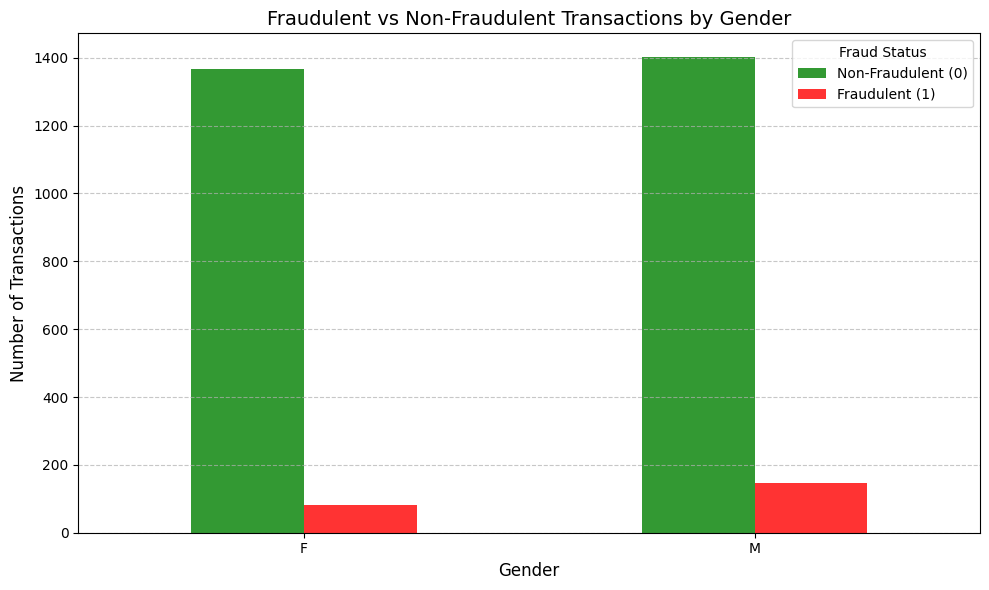

In [12]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("Modified_CreditCardData.csv")


# Group data by 'Gender' and 'Fraud' to get the counts
gender_fraud_counts = data.groupby(['Gender', 'Fraud']).size().unstack()

# Create a grouped bar graph
plt.figure(figsize=(10, 6))
gender_fraud_counts.plot(kind='bar', stacked=False, color=['green', 'red'], alpha=0.8, figsize=(10, 6))

# Add labels and title
plt.title('Fraudulent vs Non-Fraudulent Transactions by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Non-Fraudulent (0)', 'Fraudulent (1)'], title='Fraud Status', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


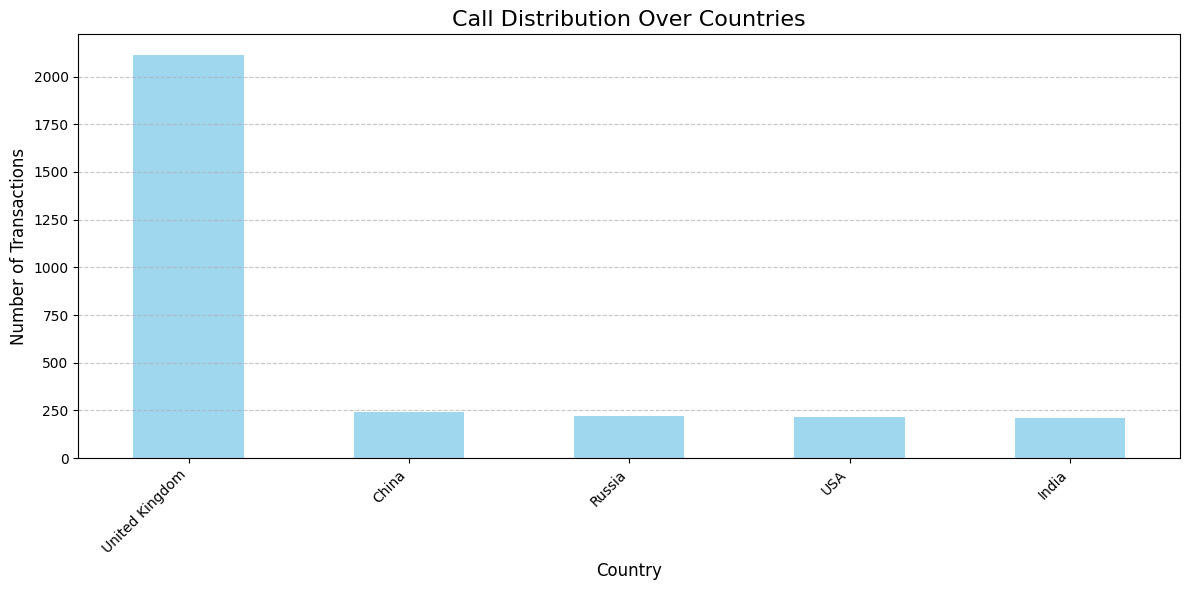

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Modified_CreditCardData.csv")
# Count the transactions per country
country_distribution = data['Country of Transaction'].value_counts()

# Create a bar chart for call distribution
plt.figure(figsize=(12, 6))
country_distribution.plot(kind='bar', color='skyblue', alpha=0.8)

# Add labels and title
plt.title('Call Distribution Over Countries', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


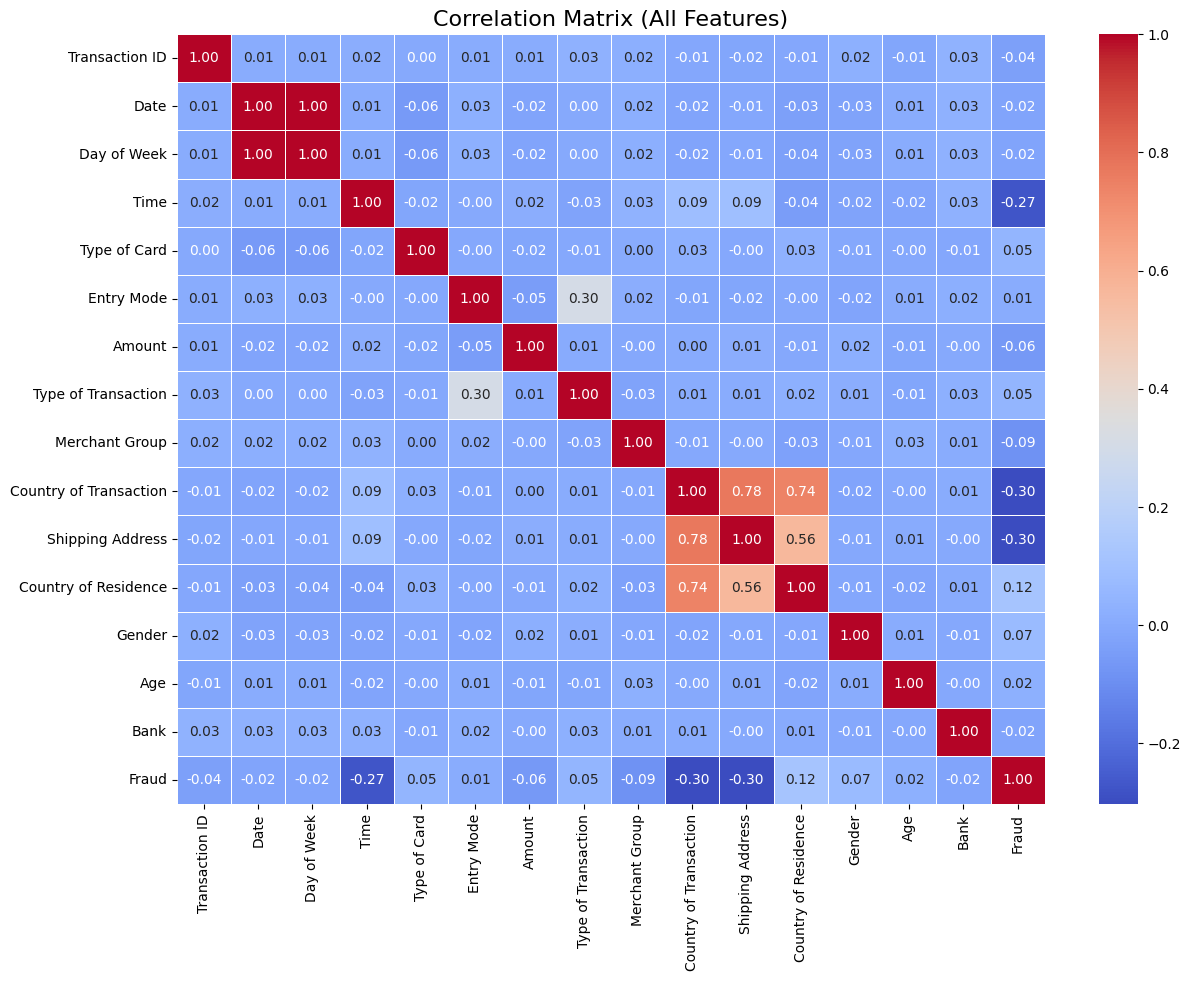

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("Modified_CreditCardData.csv")

# Encode categorical variables to numeric
data_encoded = data.copy()
for column in data.select_dtypes(include=['object']).columns:
    data_encoded[column] = data_encoded[column].astype('category').cat.codes

# Calculate the correlation matrix
correlation_matrix = data_encoded.corr()

# Plot the heatmap for the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# Add labels and title
plt.title('Correlation Matrix (All Features)', fontsize=16)
plt.show()


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Define the target column (update if different)
target_column = 'Fraud'  # Adjust this to the correct column name

# Drop irrelevant columns (if any)
irrelevant_columns = ["Day of Week"]  # Adjust as needed
df = df.drop(columns=[col for col in irrelevant_columns if col in df.columns], errors='ignore')

# Define the feature set and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Identify and handle non-numeric columns
# 1. Convert 'Merchant Group' to numerical using Label Encoding
#    This addresses the specific error caused by '#3577 209'
for col in X.select_dtypes(include=['object']).columns:
    # Create a LabelEncoder for each categorical column
    label_encoder = LabelEncoder()

    # Fit and transform the column
    X[col] = label_encoder.fit_transform(X[col])


# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Feature Selection using SelectKBest (Filter Method)
select_k_best = SelectKBest(score_func=f_classif, k='all')  # Select all features
X_k_best = select_k_best.fit_transform(X_scaled, y)
k_best_scores = select_k_best.scores_

# Create a DataFrame to view the feature names and their scores
k_best_df = pd.DataFrame({
    'Feature': X.columns,
    'Score': k_best_scores
})

# Sort features by their scores in descending order
k_best_df = k_best_df.sort_values(by='Score', ascending=False)

# Display the sorted features and their scores
print("Features selected by SelectKBest (sorted by ANOVA F-value):")
print(k_best_df)

# 2. Feature Selection using RFE (Wrapper Method)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=log_reg, n_features_to_select=1)  # Select all features but rank them
rfe.fit(X_scaled, y)

# Create a DataFrame for RFE ranking
rfe_df = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_
})

# Sort features by their RFE ranking (lower rank is better)
rfe_df = rfe_df.sort_values(by='Ranking')

# Display the sorted features by RFE ranking
print("\nFeatures ranked by RFE (Logistic Regression):")
print(rfe_df)

# Comparison of the two feature sets
common_features = set(k_best_df['Feature']).intersection(set(rfe_df['Feature']))
print(f"\nCommon features selected by both methods: {common_features}")
print(f"Features selected only by SelectKBest: {set(k_best_df['Feature']) - common_features}")
print(f"Features selected only by RFE: {set(rfe_df['Feature']) - common_features}")

# Summary of feature selection techniques
print("\nSelectKBest selects features based on their individual statistical relevance to the target variable.")
print("RFE ranks features based on their contribution to the predictive power of a model (Logistic Regression in this case).")

Features selected by SelectKBest (sorted by ANOVA F-value):
                   Feature       Score
8   Country of Transaction  303.347556
9         Shipping Address  300.107093
2                     Time  242.348462
10    Country of Residence   41.062667
7           Merchant Group   22.554482
11                  Gender   14.530520
5                   Amount   10.571943
6      Type of Transaction    6.854289
3             Type of Card    6.834270
0           Transaction ID    4.263211
12                     Age    1.628414
13                    Bank    1.413640
1                     Date    1.322672
4               Entry Mode    0.182863

Features ranked by RFE (Logistic Regression):
                   Feature  Ranking
10    Country of Residence        1
8   Country of Transaction        2
2                     Time        3
9         Shipping Address        4
7           Merchant Group        5
11                  Gender        6
5                   Amount        7
3             Type o

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       551
           1       0.67      0.53      0.59        49

    accuracy                           0.94       600
   macro avg       0.81      0.75      0.78       600
weighted avg       0.94      0.94      0.94       600

Confusion Matrix:


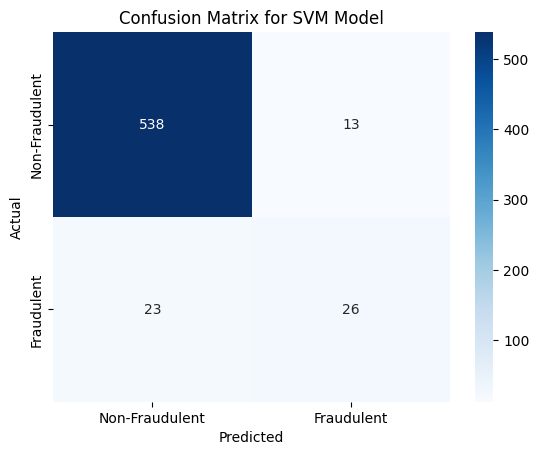

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Preprocessing: Handle missing values (if any)
data = data.dropna()  # Remove rows with missing values

# Assuming 'Fraud' column is the target and 'Gender' or other categorical features are present
# Encode categorical features if present
data_encoded = data.copy()
for column in data.select_dtypes(include=['object']).columns:
    data_encoded[column] = data_encoded[column].astype('category').cat.codes
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']
# Separate features (X) and target (y)
X = data_encoded[features] # Drop target column from features
y = data_encoded['Fraud']  # Target column (fraud or not)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling for better performance of SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVM model
svm_model = SVC(kernel='linear', random_state=42)  # You can try different kernels like 'rbf' or 'poly'
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Non-Fraudulent', 'Fraudulent'], yticklabels=['Non-Fraudulent', 'Fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Model')
plt.show()


In [14]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("Modified_CreditCardData.csv")


# Selecting relevant features and target
target = 'Fraud'
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']

# Convert 'Amount' to a numeric value by removing any non-numeric characters and converting it to float
df['Amount'] = df['Amount'].replace('[^\d.]', '', regex=True).astype(float)

# Label encode categorical features
label_encoders = {}
for col in features:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Splitting data into features and target
X = df[features]
y = df[target]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Support Vector Classifier with a linear kernel
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

# Predictions
y_pred = svc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", report)


Accuracy: 95.33%
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       822
           1       0.78      0.64      0.70        78

    accuracy                           0.95       900
   macro avg       0.87      0.81      0.84       900
weighted avg       0.95      0.95      0.95       900



In [15]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv("Modified_CreditCardData.csv")

# Selecting relevant features and target
target = 'Fraud'
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']

# Convert 'Amount' to a numeric value by removing any non-numeric characters and converting it to float
df['Amount'] = df['Amount'].replace('[^\d.]', '', regex=True).astype(float)

# Label encode categorical features
label_encoders = {}
for col in features:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Splitting data into features and target
X = df[features]
y = df[target]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Support Vector Classifier with a sigmoid kernel
svc = SVC(kernel='sigmoid')
svc.fit(X_train, y_train)

# Predictions
y_pred = svc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", report)


Accuracy: 93.44%
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       822
           1       0.69      0.45      0.54        78

    accuracy                           0.93       900
   macro avg       0.82      0.71      0.75       900
weighted avg       0.93      0.93      0.93       900



In [16]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv("Modified_CreditCardData.csv")

# Selecting relevant features and target
target = 'Fraud'
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']

# Convert 'Amount' to a numeric value by removing any non-numeric characters and converting it to float
df['Amount'] = df['Amount'].replace('[^\d.]', '', regex=True).astype(float)

# Label encode categorical features
label_encoders = {}
for col in features:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Splitting data into features and target
X = df[features]
y = df[target]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Support Vector Classifier with a polynomial kernel
svc = SVC(kernel='poly', degree=3)  # degree=3 is commonly used, but you can adjust it
svc.fit(X_train, y_train)

# Predictions
y_pred = svc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", report)


Accuracy: 95.56%
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       822
           1       0.91      0.54      0.68        78

    accuracy                           0.96       900
   macro avg       0.94      0.77      0.83       900
weighted avg       0.95      0.96      0.95       900



In [17]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv("Modified_CreditCardData.csv")


# Selecting relevant features and target
target = 'Fraud'
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']

# Convert 'Amount' to a numeric value by removing any non-numeric characters and converting it to float
df['Amount'] = df['Amount'].replace('[^\d.]', '', regex=True).astype(float)

# Label encode categorical features
label_encoders = {}
for col in features:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Splitting data into features and target
X = df[features]
y = df[target]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Support Vector Classifier with an RBF kernel
svc = SVC(kernel='rbf')
svc.fit(X_train, y_train)

# Predictions
y_pred = svc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", report)


Accuracy: 95.44%
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       822
           1       0.82      0.60      0.70        78

    accuracy                           0.95       900
   macro avg       0.89      0.80      0.84       900
weighted avg       0.95      0.95      0.95       900



In [18]:
df.Fraud.value_counts()

,count
Fraud,
0,2771
1,229


In [19]:
df = pd.read_csv("Modified_CreditCardData.csv")
X_features = list(df.columns)
X_features.remove('Fraud')
X_features

['Transaction ID',
 'Date',
 'Day of Week',
 'Time',
 'Type of Card',
 'Entry Mode',
 'Amount',
 'Type of Transaction',
 'Merchant Group',
 'Country of Transaction',
 'Shipping Address',
 'Country of Residence',
 'Gender',
 'Age',
 'Bank']

In [20]:
encoded_df = pd.get_dummies(df[X_features],drop_first = True )

In [21]:
Y = df.Fraud
X = encoded_df
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size = 0.3, random_state = 42)

In [22]:
from sklearn.tree import DecisionTreeClassifier
clf_tree = DecisionTreeClassifier(criterion = 'gini', max_depth = 5 )

In [23]:
clf_tree.fit( X_train, y_train )

DecisionTreeClassifier(max_depth=5)

In [25]:
from sklearn import metrics
from sklearn.metrics import classification_report
tree_predict = clf_tree.predict( X_test )
metrics.roc_auc_score( y_test, tree_predict )
report = classification_report(y_test, tree_predict)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       822
           1       0.85      0.82      0.84        78

    accuracy                           0.97       900
   macro avg       0.92      0.90      0.91       900
weighted avg       0.97      0.97      0.97       900



In [26]:
#####Post Pruning
from sklearn.tree import DecisionTreeClassifier
clf_tree = DecisionTreeClassifier(criterion = 'gini', max_depth = 3 )
# Fit the tree on the training data
clf_tree.fit(X_train, y_train)

# Calculate the effective alphas for pruning
path = clf_tree.cost_complexity_pruning_path(X_train, y_train)
alphas, impurities = path.ccp_alphas, path.impurities

# Choose the best alpha based on cross-validation or other criteria
# (you can also use a simple loop to explore different alpha values)
best_alpha = alphas[np.argmin(impurities)]

# Prune the tree with the chosen alpha
pruned_tree = DecisionTreeClassifier(random_state=0, criterion = 'entropy',ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

tree_predict = pruned_tree.predict( X_test )
metrics.roc_auc_score( y_test, tree_predict )
report = classification_report(y_test, tree_predict)
print("Classification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       822
           1       0.81      0.73      0.77        78

    accuracy                           0.96       900
   macro avg       0.89      0.86      0.87       900
weighted avg       0.96      0.96      0.96       900



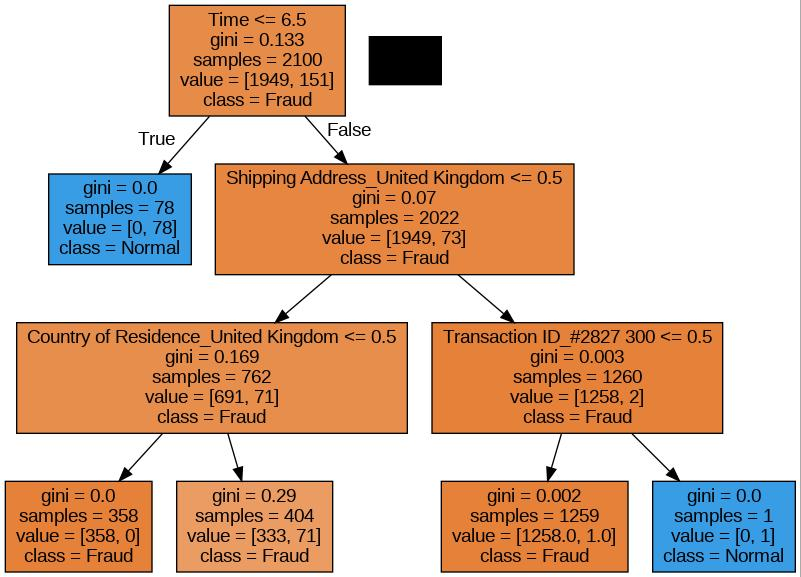

In [27]:
from sklearn.tree import export_graphviz
import pydotplus as pdot
from IPython.display import Image
# Export the tree into odt file
export_graphviz( clf_tree, out_file = "chd_tree.odt", feature_names = X_train.columns, class_names= ['Fraud', 'Normal'], filled = True)
# Read the create the image file
chd_tree_graph = pdot.graphviz.graph_from_dot_file( 'chd_tree.odt' )
chd_tree_graph.write_jpg( 'chd_tree.png' )
# Render the png file
Image(filename='chd_tree.png')

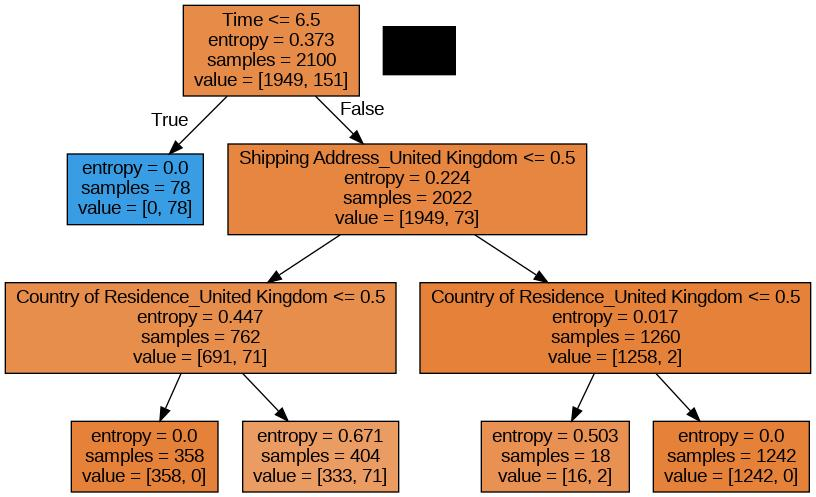

In [28]:
clf_tree_entropy = DecisionTreeClassifier( criterion = 'entropy',max_depth = 3 )
clf_tree_entropy.fit( X_train, y_train )
# Export the tree into odt file
export_graphviz( clf_tree_entropy, out_file = "chd_tree_entropy.odt", feature_names = X_train.columns, filled = True )
# Read the create the image file
chd_tree_graph = pdot.graphviz.graph_from_dot_file( 'chd_tree_entropy.odt' )
chd_tree_graph.write_jpg( 'chd_tree_entropy.png' )
# Render the png file
Image(filename='chd_tree_entropy.png')

In [29]:
from sklearn import metrics
tree_predict = clf_tree_entropy.predict( X_test )
metrics.roc_auc_score( y_test, tree_predict )
report = classification_report(y_test, tree_predict)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       822
           1       1.00      0.46      0.63        78

    accuracy                           0.95       900
   macro avg       0.98      0.73      0.80       900
weighted avg       0.96      0.95      0.95       900



In [30]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
data = pd.read_csv("Modified_CreditCardData.csv")

# Preview the dataset
print(data.head())
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']
# Preprocessing
# Assuming the target column is named 'Class' (1 = Fraud, 0 = Non-Fraud)
X = data[features]
y = data['Fraud']

# Handle categorical features (if any)
X = pd.get_dummies(X, drop_first=True)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define a chaotic logistic map
def logistic_map(size, r=3.99, x0=0.5):
    """Generates a chaotic sequence using the logistic map."""
    chaos = np.zeros(size)
    chaos[0] = x0
    for i in range(1, size):
        chaos[i] = r * chaos[i - 1] * (1 - chaos[i - 1])
    return chaos

# Generate chaotic sequence for feature selection
num_features = X_train.shape[1]
num_iterations = 100  # Or a desired number of chaotic values

# Ensure chaotic sequence length matches num_features
chaotic_sequence = logistic_map(num_features, x0=0.7)

# Feature selection using chaotic sequence
best_features = []
max_accuracy = 0

for iteration in range(num_iterations):
    # Threshold chaotic values to select features
    threshold = chaotic_sequence[iteration % num_features]  # Wrap iteration using modulo
    selected_features = np.where(chaotic_sequence > threshold, 1, 0)

    # Reduce features based on selection
    reduced_X_train = X_train[:, selected_features == 1]
    reduced_X_test = X_test[:, selected_features == 1]

    # Train a model on selected features
    clf = RandomForestClassifier(random_state=42)
    clf.fit(reduced_X_train, y_train)
    y_pred = clf.predict(reduced_X_test)

    # Evaluate the model
    acc = accuracy_score(y_test, y_pred)

    # Update best features if accuracy improves
    if acc > max_accuracy:
        max_accuracy = acc
        best_features = selected_features

print(f"Best Accuracy: {max_accuracy}")

# Final model training with the best features
final_X_train = X_train[:, best_features == 1]
final_X_test = X_test[:, best_features == 1]
final_clf = RandomForestClassifier(random_state=42)
final_clf.fit(final_X_train, y_train)
final_y_pred = final_clf.predict(final_X_test)
final_accuracy = accuracy_score(y_test, final_y_pred)

print(f"Final Model Accuracy: {final_accuracy}")


  Transaction ID       Date Day of Week  Time Type of Card Entry Mode Amount  \
0      #3577 209  14-Oct-20   Wednesday    19         Visa        Tap     £5   
1      #3039 221  14-Oct-20   Wednesday    17   MasterCard        PIN   £288   
2      #2694 780  14-Oct-20   Wednesday    14         Visa        Tap     £5   
3      #2640 960  13-Oct-20     Tuesday    14         Visa        Tap    £28   
4      #2771 031  13-Oct-20     Tuesday    23         Visa        CVC    £91   

  Type of Transaction Merchant Group Country of Transaction Shipping Address  \
0                 POS  Entertainment         United Kingdom   United Kingdom   
1                 POS       Services                    USA              USA   
2                 POS     Restaurant                  India            India   
3                 POS  Entertainment         United Kingdom            India   
4              Online    Electronics                    USA              USA   

  Country of Residence Gender   Age   

In [31]:
# Step 1: Install Required Libraries
!pip install tensorflow scikit-learn

# Step 2: Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Step 3: Load and Prepare the Dataset
data = pd.read_csv("Modified_CreditCardData.csv")
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']
# Assuming your dataset has features in 'X' and target in 'y'
X = data[features]  # Replace 'target' with your actual target column name
y = data['Fraud'].values  # Replace 'target' with your actual target column name

X = pd.get_dummies(X, drop_first=True) # One-hot encode categorical features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert DataFrames to NumPy arrays before reshaping
X_train = X_train.values.astype(np.float32) # Convert to float32
X_test = X_test.values.astype(np.float32)   # Convert to float32

# Step 4: Reshape the Data for LSTM (3D input)
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Step 5: Build and Train the LSTM Model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dropout(0.2))  # Dropout layer for regularization
lstm_model.add(Dense(units=1, activation='sigmoid'))  # Sigmoid for binary classification

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))

# Step 6: Train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 7: Make Predictions
# LSTM Model Predictions
lstm_predictions = lstm_model.predict(X_test_lstm).flatten()
lstm_predictions = (lstm_predictions > 0.5).astype(int)  # Convert probabilities to class labels

# Random Forest Model Predictions
rf_predictions = rf_model.predict(X_test)

# Step 8: Combine LSTM and RF Predictions (Ensemble)
ensemble_predictions = np.round((lstm_predictions + rf_predictions) / 2).astype(int)

# Step 9: Evaluate the Models
lstm_accuracy = accuracy_score(y_test, lstm_predictions)
rf_accuracy = accuracy_score
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions)

# Print the accuracies of all models
print(f'LSTM Model Accuracy: {lstm_accuracy}')
print(f'Random Forest Accuracy: {rf_accuracy}')
print(f'Ensemble Model Accuracy: {ensemble_accuracy}')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8701 - loss: 0.3758 - val_accuracy: 0.9217 - val_loss: 0.2469
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9175 - loss: 0.2557 - val_accuracy: 0.9217 - val_loss: 0.2058
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9312 - loss: 0.1977 - val_accuracy: 0.9283 - val_loss: 0.1710
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9549 - loss: 0.1459 - val_accuracy: 0.9450 - val_loss: 0.1340
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9592 - loss: 0.1104 - val_accuracy: 0.9617 - val_loss: 0.1070
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9686 - loss: 0.0834 - val_accuracy: 0.9650 - val_loss: 0.0984
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9772 - loss: 0.0694 - val_accuracy: 0.9650 - val_loss: 0.0901
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9837 - loss: 0.0573 - val_accuracy: 0.9617 - v

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder


# Load your dataset
data = pd.read_csv("Modified_CreditCardData.csv")
features = ['Country of Residence','Country of Transaction','Time','Shipping Address','Gender','Transaction ID','Bank','Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']
# Assume 'target' is the label column
X = data[features]  # Features
y = data['Fraud']  # Target

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Iterate through categorical columns and apply Label Encoding
for col in X.select_dtypes(include=['object']).columns: # Select columns with 'object' dtype
    X[col] = label_encoder.fit_transform(X[col])


# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

<ipython-input-32-45ea672ef416>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col])
<ipython-input-32-45ea672ef416>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col])
<ipython-input-32-45ea672ef416>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

Accuracy: 0.97
Confusion Matrix:
 [[552   1]
 [ 17  30]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       553
           1       0.97      0.64      0.77        47

    accuracy                           0.97       600
   macro avg       0.97      0.82      0.88       600
weighted avg       0.97      0.97      0.97       600



In [47]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Load the Iris dataset
data = pd.read_csv("Modified_CreditCardData.csv")
features = ['Country of Residence', 'Country of Transaction', 'Time', 'Shipping Address', 'Gender', 'Transaction ID', 'Bank', 'Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']
# Assume 'target' is the label column
X = data[features]  # Features
y = data['Fraud']  # Target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Iterate through categorical columns and apply Label Encoding
for col in X.select_dtypes(include=['object']).columns:  # Select columns with 'object' dtype
    # Fit on the combined data (train and test)
    combined_data = pd.concat([X_train[col], X_test[col]], axis=0)
    label_encoder.fit(combined_data.astype(str)) # Fit on string representation

    X_train[col] = label_encoder.transform(X_train[col].astype(str))
    X_test[col] = label_encoder.transform(X_test[col].astype(str))

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

# Make predictions
y_pred = mlp.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"MLPClassifier Accuracy: {accuracy:.2f}")

# Print Precision, Recall, and F1-Score
print("\nClassification Report:")
# Assuming you want to print the report for the credit card data, not iris
print(classification_report(y_test, y_pred))

MLPClassifier Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       822
           1       0.70      0.67      0.68        78

    accuracy                           0.95       900
   macro avg       0.84      0.82      0.83       900
weighted avg       0.95      0.95      0.95       900



In [51]:
###ANN code for classification_report

####ANN- one hidden layer -10 nodes, input has 4 nodes and output has 3 nodes based on iris dataset
###relu activation fn is applied
###u can make variations here


import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder # Import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Load the Iris dataset
data = pd.read_csv("Modified_CreditCardData.csv")
features = ['Country of Residence', 'Country of Transaction', 'Time', 'Shipping Address', 'Gender', 'Transaction ID', 'Bank', 'Amount', 'Age', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group']
# Assume 'target' is the label column
X = data[features]  # Features
y = data['Fraud']  # Target


# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Iterate through categorical columns and apply Label Encoding
for col in X.select_dtypes(include=['object']).columns:  # Select columns with 'object' dtype
    # Fit on the combined data (train and test)
    X[col] = label_encoder.fit_transform(X[col].astype(str)) # Fit on string representation

# Convert to PyTorch tensors
X = torch.tensor(X.values, dtype=torch.float32)  # Convert DataFrame to NumPy array first
y = torch.tensor(y.values, dtype=torch.long)    # Convert Series to NumPy array first


# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train.numpy()), dtype=torch.float32) # Convert back to tensor
X_test = torch.tensor(scaler.transform(X_test.numpy()), dtype=torch.float32)      # Convert back to tensor

# Define the ANN model
class ANN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Model parameters
input_size = X.shape[1]
hidden_size = 10
output_size = len(torch.unique(y)) # infer output size from target variable

# Initialize model, loss, and optimizer
model = ANN(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Testing the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    _, predicted = torch.max(y_pred, 1)

# Calculate accuracy
accuracy = accuracy_score(y_test.numpy(), predicted.numpy()) # Convert to NumPy for accuracy_score
print(f"\nPyTorch ANN Accuracy: {accuracy:.2f}")

<ipython-input-51-c4175a1a1891>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col].astype(str)) # Fit on string representation
<ipython-input-51-c4175a1a1891>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col].astype(str)) # Fit on string representation
<ipython-input-51-c4175a1a1891>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

Epoch [100/1000], Loss: 0.1157
Epoch [200/1000], Loss: 0.0947
Epoch [300/1000], Loss: 0.0813
Epoch [400/1000], Loss: 0.0735
Epoch [500/1000], Loss: 0.0667
Epoch [600/1000], Loss: 0.0608
Epoch [700/1000], Loss: 0.0567
Epoch [800/1000], Loss: 0.0540
Epoch [900/1000], Loss: 0.0525
Epoch [1000/1000], Loss: 0.0499

PyTorch ANN Accuracy: 0.95
